In [29]:
import numpy as np
import matplotlib.pyplot as plt
import math
pi = math.pi

In [30]:

low =100
high = 300

def binary_search(low, high, test_func, tol=1e-7):
    """
    Generic continuous binary search engine.
    """
    while (high - low) > tol:
        mid = (low + high) / 2.0
        positive_test = test_func(mid)
        if positive_test:
            low = mid
        else:
            high = mid

    return (low + high) / 2.0



def least_M(search_low,search_high,ETA,k_param,TAU):
    # Initialize boundaries for the binary/logarithmic search

    def the_test():
        if search_low < 10000:
            return log_M_condition_fct(test_high,ETA,k_param,TAU) < 0
        else:
            return log_M_condition_fct(test_high,ETA,k_param,TAU) > 0

    # A tolerance threshold determines how precise you want the boundary to be.
    # 1e-5 is usually plenty, but you can adjust it based on your precision needs.

    while (search_high - search_low) > 1e-7:
        # Find the midpoint of the current window
        test_high = (search_low + search_high) / 2.0

        if the_test():
            # This point is safe! Save it, and try to push higher.
            adjusted_high = test_high
            search_low = test_high
        else:
            # Asymptotic flip hit. We need to look lower.
            search_high = test_high

    return test_high




In [31]:
def log_M_condition_fct(log_M, Eta, K,Tau): #threshold is NEGATIVE
    # if threshold_for_m >= 0:
    #     return False


    log_M_eta = np.pow(log_M,Eta-1)
    m_tau = np.exp(log_M*(1-2*Tau))# - 2/np.exp(log_M*2*Tau)
    # print(f"m^(1-2τ) = {m_tau}")
    # Using np.log and python's native ** power operator
    terms= [
            2 - m_tau/log_M,
            K*log_M_eta,
            -K*np.log(K)*log_M_eta,
            -K*Eta*log_M_eta*np.log(log_M),
            # K*log_M_eta*np.log(m_tau),
            K*log_M_eta*(1-2*Tau)*log_M,
        ]
    # print(term1+term2-term3)
    return sum(terms)*log_M

def binary_entropy(p):
    if p <= 0 or p >= 1:
        return 0.0
    # np.log2 works on floats; if using arrays, use np.log2
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

def m_func(value,Zeta, Log_space=False):
    if Log_space:
        return np.ceil(np.exp(value*Zeta))
    else:
        return np.ceil(np.power(value,Zeta))

def C_epsilon(Epsilon): #H(ε) + H(ε')(1-ε) + ˜ε log ˜ε − ˜ε
    Epsilon_prime = Epsilon/(1-Epsilon)
    return binary_entropy(Epsilon) + binary_entropy(Epsilon_prime)*(1-Epsilon) + Epsilon*np.log(Epsilon) - Epsilon

def exps_bound_of_Ee(value,Epsilon,Delta,Zeta):
    L_term = 3*Epsilon + 4*Zeta*(Delta-Epsilon) -2*Delta
    #linear term is δ(4ζ-2) + ε(3-4ζ)
    log_alpha = Delta*np.log(3/2)+(Epsilon-Delta)*np.log(3*Delta)
    constant_term = 2*Delta + 2*log_alpha + C_epsilon(Epsilon)

    C = np.pow(2*pi,3/2)* Delta*Epsilon*np.sqrt((1-2*Epsilon)/2)
    exp_term = -3*value/2 -np.log(C)
    result = constant_term + value*L_term + np.exp(-value)*exp_term
    print(constant_term,L_term)
    return result

In [32]:
def gamma_n(value,Zeta,Delta,Omega,Tau):
    n_value = np.exp(value)
    M1 = np.exp(value*Zeta)
    return Delta**2/4 - Delta/(4*n_value) - 16*np.power(M1,1-2*Tau)/np.power(np.log(M1),2*Omega) - 2*Delta/M1

def A_condition(value,Zeta,Delta,Epsilon,Omega,Tau,K,Eta):
    #value represents L = log n
    Gamma = gamma_n(value=value,Zeta=Zeta,Delta=Delta,Omega=Omega,Tau=Tau)
    C_k = 4*np.exp(2)*(2*K+1)**2 + 2*np.exp(2)
    M1 = np.exp(value*Zeta)
    log_M = Zeta*value

    Term1 = -Gamma/(C_k*np.power(M1,2*Tau)*np.power(log_M,2*Eta+2*Omega)) * np.power(1-1/log_M**Omega,4*K*log_M**Eta)

    Term2 = C_epsilon(Epsilon)
    #constant term

    # c=ε sqrt[2π(1 − 2ε)/2].
    c = Epsilon*np.sqrt(pi*(1-2*Epsilon)/2)
    Term3 = -value/2 - np.log(c)
    #coupled with e^-L
    Term4 = Epsilon
    #coupled with L
    return Term1*np.exp(value) +Term2+Term3*np.exp(-value)+ Term4*value  #+ 1/(12*Epsilon)*np.exp(-2*value)

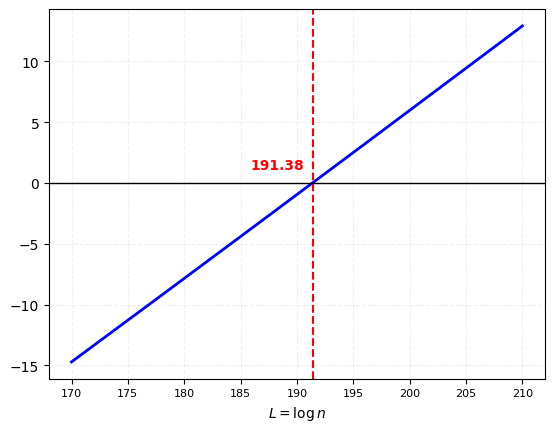

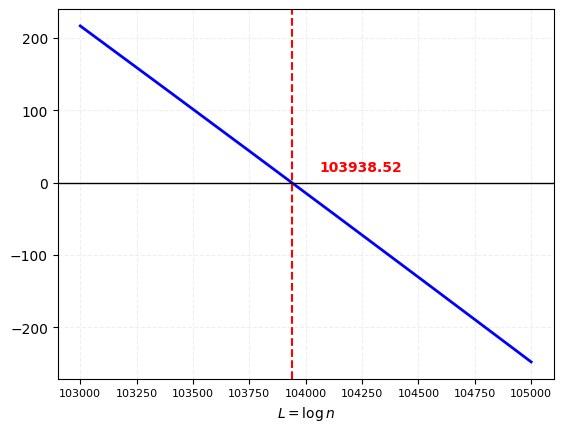

In [74]:
ZETA= 8e-01
k_param=28.5
TAU=0.5065
ETA=0.148505


# 2. Generate x values
# np.linspace(start, stop, number_of_points)
# 400 points provides a smooth curve for most functions
intervals = [[170,210],[103000,105000]]

for interval in intervals:
    L_min = interval[0]
    L_max = interval[1]
    L = np.linspace(L_min, L_max, 400)
    M = ZETA*L
    search_min = ZETA*L_min
    search_max = ZETA*L_max
    supa_L = least_M(search_min,search_max,ETA,k_param,TAU)/ZETA
    # 3. Calculate y values
    y = log_M_condition_fct(M, ETA, k_param, TAU)

    # 4. Create the plot
    figsize=(17, 10)

    plt.plot(L, y, label=r'$\tau= $' + f'{TAU}', color='blue', linewidth=2)
    plt.axvline(x=supa_L, color='red', linestyle='--', linewidth=1.5)
    if supa_L < 10000:
        tag_pos = (-45,10)
    else:
        tag_pos = (20,8)

    plt.annotate(f'{round(supa_L,2)}',
                 xy=(supa_L, 0),                 # The exact coordinate to anchor to
                 xytext=tag_pos,               # Shift text 8 pixels right, 8 pixels up
                 textcoords='offset points',  # Tells matplotlib to use pixels for the shift
                 color='red',
                 fontweight='bold',
                 fontsize=10)

    # 5. Customize the plot's appearance
    # plt.title(r'Plot of $f_\mathcal{T}$ in the region ' + f'[{L_min:.2e},{L_max:.2e}],'+r' with $\zeta =$' + f'{round(ZETA,3)}' + ' ,k ='+f'{round(k_param,3)}' + r',$\tau =$' + f'{TAU}', fontsize=14)
    plt.xlabel(r'$L = \log n$', fontsize=10)
    # plt.ylabel(r'$f_\mathcal{T}(L)$', fontsize=12)
    plt.xticks(fontsize=8)

    # Add a subtle grid
    plt.grid(True, linestyle='--', alpha=0.2)


    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Highlight the x and y axes (where x=0 and y=0)
    plt.axhline(y=0, color='black', linewidth=1)

    # plt.axvline(x=100, color='black', linewidth=1)

    # Display the legend
    # plt.legend()

    # 6. Render the plot
    plt.show()

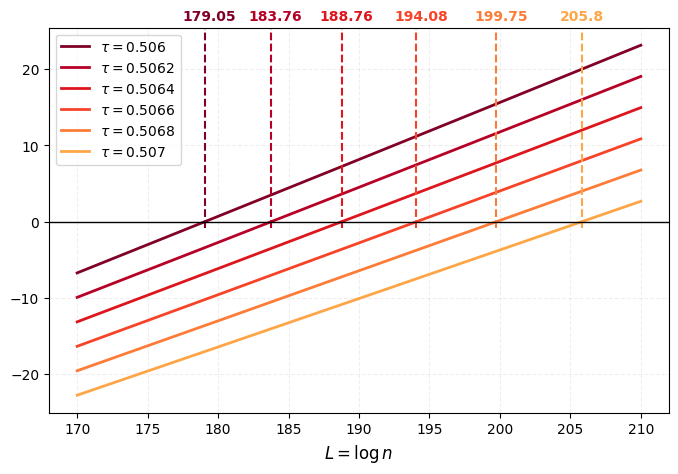

In [50]:
ZETA= 8e-01
DELTA = 4.234044105657223e-02
OMEGA= 1.022529534106635
k_param=28.5
TAU=0.505914402992784
ETA=0.148505

TAUS = [0.506,0.5062,0.5064,0.5066,0.5068,0.507]
cmap = plt.get_cmap('YlOrRd_r')
# 2. Generate x values
# np.linspace(start, stop, number_of_points)
# 400 points provides a smooth curve for most functions
L_min = 170
L_max = 210
L = np.linspace(L_min, L_max, 400)
M = ZETA*L
search_min = ZETA*L_min
search_max = ZETA*L_max
plt.figure(figsize=(8, 5))
for i,TAU in enumerate(TAUS):
    supa_L = least_M(search_min,search_max,ETA,k_param,TAU)/ZETA
    # 3. Calculate y values
    y = log_M_condition_fct(M, ETA, k_param, TAU)

    # 4. Create the plot
    # figsize=(width, height) in inches

    color = cmap(i*0.7/len(TAUS))
    plt.plot(L, y, label=r'$\tau= $' + f'{TAU}', color=color, linewidth=2)
    plt.axvline(x=supa_L, color=color, ymin=0.48, linestyle='--', linewidth=1.5)
    if supa_L < 10000:
        tag_pos = (-16,145)
    else:
        tag_pos = (20,8)

    plt.annotate(f'{round(supa_L,2)}',
                 xy=(supa_L, 0),                 # The exact coordinate to anchor to
                 xytext=tag_pos,               # Shift text 8 pixels right, 8 pixels up
                 textcoords='offset points',  # Tells matplotlib to use pixels for the shift
                 color=color,
                 fontweight='bold',
                 fontsize=10)

# 5. Customize the plot's appearance
# plt.title(r'Plot of $f_\mathcal{T}$ in the region ' + f'[{L_min:.2e},{L_max:.2e}],'+r' with $\zeta =$' + f'{round(ZETA,3)}' + ' ,k ='+f'{round(k_param,3)}' + r',$\tau =$' + f'{TAU}', fontsize=14)
plt.xlabel(r'$L = \log n$', fontsize=12)
# plt.ylabel(r'$f_\mathcal{T}(L)$', fontsize=12)

# Add a subtle grid
plt.grid(True, linestyle='--', alpha=0.2)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Highlight the x and y axes (where x=0 and y=0)
plt.axhline(y=0, color='black', linewidth=1)
# plt.axvline(x=100, color='black', linewidth=1)

# Display the legend
plt.legend()

# 6. Render the plot
plt.show()

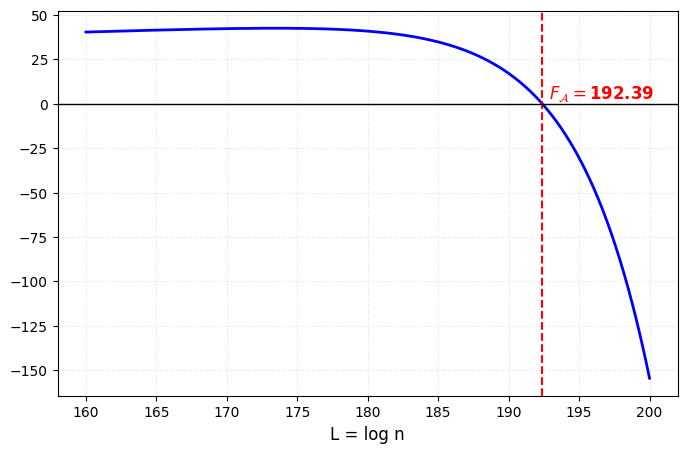

In [35]:
L_min = 160
L_max = 200
ZETA= 8e-01
DELTA = 0.042
OMEGA= 1.003
k_param=28.5
TAU=0.5065
ETA=0.148



L = np.linspace(L_min, L_max, 400)
M = ZETA*L

F_A = binary_search(low,high, lambda x:not (A_condition(value=x,Zeta=ZETA,Epsilon=1/4,Delta=DELTA,Omega=OMEGA,Tau=TAU,K=k_param,Eta=ETA)<-1e-60 ) )

# supa_L = least_L(search_low=L_min,search_high=L_max,ZetA=ZETA,OmEGA=OMEGA,k_PARAM=k_param,EtA=ETA,TaU=TAU)
# 3. Calculate y values
y = A_condition(value=L, Zeta=ZETA, Epsilon=1/4,
                              K=k_param, Tau=TAU, Omega=OMEGA, Eta=ETA,Delta=DELTA)

# y = exps_bound_of_Ee(value=L, Epsilon=1/4,Zeta=ZETA,Delta=DELTA)
# y = fct(value=L,zeta=ZETA,tau=TAU,k=k_param,eta=ETA)
# 4. Create the plot
# figsize=(width, height) in inches
plt.figure(figsize=(8, 5))
plt.plot(L, y, label=r'$f_\mathcal{T}$', color='blue', linewidth=2)

# 5. Customize the plot's appearance

plt.xlabel('L = log n', fontsize=12)

# Add a subtle grid
plt.grid(True, linestyle='--', alpha=0.2)
if F_A < 10000:
    tag_pos = (5,5)
else:
    tag_pos = (20,8)
plt.axvline(x=F_A, color='red', linestyle='--', linewidth=1.5)
plt.annotate(r'$F_{\mathcal{A}}=$'+f'{round(F_A,2)}',
             xy=(F_A, 0),                 # The exact coordinate to anchor to
             xytext=tag_pos,               # Shift text 8 pixels right, 8 pixels up
             textcoords='offset points',  # Tells matplotlib to use pixels for the shift
             color='red',
             fontweight='bold',
             fontsize=12)

plt.axhline(y=0, color='black', linewidth=1)

# Display the legend
# plt.legend()

# 6. Render the plot

plt.show()

